# Kết hợp MLP với Logic mờ (Mamdani Fuzzy) — Phát hiện đăng nhập rủi ro (RBA)

**Môn:** Học Máy Nâng Cao — Báo cáo cuối kỳ
**Giảng viên hướng dẫn:** TS. Phan Thị Huyền Trang
**Nhóm 10** — Lê Phú Nhân (2591317) · Phạm Trung Kiên (2591310) · Nguyễn Minh Tuấn (2591325)
**Lớp:** KHMT 2025B — Trường ĐH Sư phạm Kỹ thuật TP.HCM

---

## Đề tài
Kết hợp **MLP (Multi-Layer Perceptron)** với **logic mờ Mamdani (Fuzzy Logic)** cho
bài toán **Risk-Based Authentication (RBA)**: chấm điểm rủi ro cho mỗi lượt đăng
nhập và dự đoán lượt đó có đến từ **IP tấn công** hay không (phân loại nhị phân).

Hệ mờ Mamdani biến 5 đặc trưng ngữ cảnh thành **điểm rủi ro + 15 mức độ thuộc mờ**;
các đặc trưng này được đưa **thẳng vào MLP** làm đầu vào (hợp nhất ở *tầng đặc trưng*).

## Cách chạy notebook
- **Trên Google Colab:** chạy lần lượt từ trên xuống. Nếu có sẵn file dữ liệu thật
  `rba_sample_500k.csv` thì đặt vào `rba_local_project/data/`, notebook sẽ tự dùng
  dữ liệu thật; nếu không, notebook **tự sinh một mẫu mô phỏng đúng lược đồ** để
  toàn bộ pipeline vẫn chạy được end-to-end (mục 2–9).
- **Kết quả CHÍNH THỨC của đồ án** (huấn luyện trên **500.000 dòng dữ liệu thật** —
  *Login Data Set for RBA*, Wiefling và cộng sự) được nạp trực tiếp từ
  `rba_local_project/outputs/` ở **mục 10–11** (metrics, biểu đồ, model thật).

> Mọi cell đều đã được chạy sẵn và lưu kết quả bên dưới.

## Pseudo-code thuật toán tổng quát

Trước khi đi vào từng cell code chi tiết, sơ đồ dưới đây thể hiện liên kết
đầu vào–đầu ra giữa các bước, từ log đăng nhập thô đến xác suất tấn công
cuối cùng.

```text
ALGORITHM  RBA-RiskScore(login_log L)
INPUT  : L = { user_id, timestamp, country, asn, device, os, browser,
               login_successful, round_trip_time, ... }
OUTPUT : attack_probability ∈ [0, 1]

──────────────────────────────────────────────────────────────
BƯỚC A · FEATURE ENGINEERING(L) → F                 (Bước 7-8)
──────────────────────────────────────────────────────────────
  F.time      ← hour_of_day, day_of_week, is_odd_hour
  F.rarity    ← country_rarity, asn_rarity                  (tần suất toàn cục)
  F.history   ← is_new_country/asn/device/os,
                time_since_last_login_h,
                user_success_rate_so_far, num_changes        (chỉ dùng shift()
                                                                về QUÁ KHỨ của
                                                                cùng user)

──────────────────────────────────────────────────────────────
BƯỚC B · FUZZY LOGIC(F) → Z                       (Bước 9, Mamdani FIS)
──────────────────────────────────────────────────────────────
  for each biến liên tục v ∈ {gap, country_rarity, asn_rarity,
                               success_rate, num_changes}:
        (low, med, high) ← FUZZIFY(v, ngưỡng percentile q20/q50/q80 trên train)

  for each luật Rᵢ ∈ RULEBASE (8 luật IF-THEN, AND=min, OR=max):
        firingᵢ ← EVALUATE(Rᵢ, low, med, high)

  agg  ← AGGREGATE(firing₁..₈, tập mờ output LOW/MED/HIGH)      # max-clip
  Z.mamdani_risk_score ← DEFUZZIFY(agg)                          # centroid
  Z.fz_*               ← toàn bộ 15 giá trị membership

──────────────────────────────────────────────────────────────
BƯỚC C · PREPROCESSING(F, Z) → X                  (Bước 10-11)
──────────────────────────────────────────────────────────────
  split(L) → train / val / test                      (70/15/15, stratified)
  scaler ← fit StandardScaler(F.numeric | train)
  ohe    ← fit OneHotEncoder(F.device_type | train)
  fis    ← fit MamdaniFuzzyRiskSystem(F | train)
  X ← concat( scaler.transform(F.numeric),
              ohe.transform(F.device_type),
              fis.transform(F) )

──────────────────────────────────────────────────────────────
BƯỚC D · MLP FORWARD(X) → ŷ                        (Bước 12)
──────────────────────────────────────────────────────────────
  h ← X
  for hidden_dim ∈ (128, 64, 32):
        h ← Dropout( BatchNorm( ReLU( Linear(h, hidden_dim) ) ) )
  logit ← Linear(h, 1)
  ŷ     ← sigmoid(logit)                          # attack_probability

──────────────────────────────────────────────────────────────
BƯỚC E · TRAINING (chỉ ở pha huấn luyện)          (Bước 13-14)
──────────────────────────────────────────────────────────────
  loss ← BCEWithLogits(logit, y_true; pos_weight = n_neg/n_pos)
  ∇θ   ← Backward(loss)
  θ    ← θ − Adam_update(∇θ, lr=1e-3, weight_decay=1e-5)
  lặp lại theo mini-batch (4096 mẫu) × tối đa 30 epoch
  dừng sớm nếu val_AUPRC không cải thiện sau 5 epoch

RETURN ŷ = attack_probability
```


## 1. Cài đặt & nạp thư viện

In [1]:
# Trên Colab, bỏ dấu # ở dòng dưới nếu thiếu thư viện:
# !pip install torch scikit-learn pandas numpy matplotlib -q

import os, json, pickle, time, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (roc_auc_score, average_precision_score,
    precision_recall_fscore_support, accuracy_score, confusion_matrix,
    roc_curve, precision_recall_curve)
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("torch   :", torch.__version__)
print("sklearn :", sklearn.__version__)

numpy   : 2.2.6
pandas  : 2.3.3
torch   : 2.9.1+cpu
sklearn : 1.8.0


## 2. Cấu hình & siêu tham số

Các đường dẫn tự nhận biết môi trường: nếu đang ở Colab và chưa có mã nguồn thì
tự `git clone` repo về; ngược lại dùng thư mục hiện tại.

In [2]:
# ---- Định vị repo (Colab tự clone nếu cần) ----
REPO_ROOT = os.getcwd()
if not os.path.isdir(os.path.join(REPO_ROOT, "rba_local_project")):
    try:
        import google.colab  # noqa: F401
        os.system("git clone -q https://github.com/2591317-student/MachineLearningAdvance.git")
        REPO_ROOT = os.path.join(os.getcwd(), "MachineLearningAdvance")
    except Exception:
        pass

OUTPUT_DIR = os.path.join(REPO_ROOT, "rba_local_project", "outputs")
DATA_PATH  = os.path.join(REPO_ROOT, "rba_local_project", "data", "rba_sample_500k.csv")

# ---- Cột & nhãn ----
TARGET_COLUMN = "Is Attack IP"

# ---- Siêu tham số ----
RANDOM_STATE   = 42
TEST_SIZE      = 0.30      # tách 30% làm (val+test)
VAL_TEST_SPLIT = 0.50      # trong 30% đó chia đôi -> tổng thể 70/15/15
EPOCHS         = 30
BATCH_SIZE     = 4096
LEARNING_RATE  = 1e-3
HIDDEN_DIMS    = (128, 64, 32)
DROPOUT        = 0.3
EARLY_STOPPING_PATIENCE = 5
FUZZY_OUTPUT_GRID_POINTS = 51

print("Đã định vị mã nguồn dự án:", os.path.isdir(os.path.join(REPO_ROOT, "rba_local_project")))
print("Có dữ liệu thật 500k?", os.path.exists(DATA_PATH), "(nếu False -> tự dùng mẫu mô phỏng để minh họa)")
print(f"Kiến trúc ẩn: {HIDDEN_DIMS} | epochs={EPOCHS} | batch={BATCH_SIZE} | lr={LEARNING_RATE}")

Đã định vị mã nguồn dự án: True
Có dữ liệu thật 500k? False (nếu False -> tự dùng mẫu mô phỏng để minh họa)
Kiến trúc ẩn: (128, 64, 32) | epochs=30 | batch=4096 | lr=0.001


## 3. Nạp dữ liệu

Bộ dữ liệu thật ~500.000 lượt đăng nhập, chỉ **~3%** là tấn công (mất cân bằng
nặng). Vì file gốc nặng ~140MB nên **không nằm trong git**. Nếu không có file
thật, cell dưới sinh một **mẫu mô phỏng đúng lược đồ** (cùng tên cột, cùng bản
chất tín hiệu: tấn công gắn với quốc gia/ASN lạ, giờ bất thường, tỉ lệ đăng nhập
thành công thấp) để notebook chạy được trọn vẹn.

In [3]:
def make_synthetic_rba(n_users=800, seed=RANDOM_STATE):
    """Sinh dữ liệu RBA mô phỏng đúng lược đồ dataset thật (chỉ để demo pipeline)."""
    rng = np.random.default_rng(seed)
    countries = ["US","VN","JP","DE","FR","IN","BR","GB"]
    country_p = np.array([.35,.20,.12,.09,.08,.07,.05,.04])
    asns      = [f"AS{n}" for n in (7922,4713,2516,3320,3215,9829,4230,45899)]
    devices   = ["desktop","mobile","tablet","bot"]
    browsers  = ["Chrome 120","Firefox 121","Safari 17","Edge 120"]
    oses      = ["Windows 10","Android 14","iOS 17","Ubuntu 22"]
    rows = []
    t0 = pd.Timestamp("2020-02-01")
    for uid in range(n_users):
        n_log = rng.integers(3, 15)
        home_c = rng.choice(len(countries), p=country_p)
        home_a = rng.integers(0, len(asns)); home_d = rng.integers(0, len(devices)-1)
        t = t0 + pd.Timedelta(hours=int(rng.integers(0, 8000)))
        for _ in range(n_log):
            t = t + pd.Timedelta(hours=float(rng.exponential(48)))
            is_attack = rng.random() < 0.03
            # Tín hiệu CHỒNG LẤN có chủ đích (dữ liệu thật không tách bạch hoàn toàn):
            # tấn công chỉ "thiên về" bất thường theo xác suất, người dùng thật
            # thỉnh thoảng cũng đổi nước/đăng nhập giờ lạ -> mô hình phải học, không
            # thể phân tách tuyệt đối.
            if is_attack:                          # tấn công: THIÊN VỀ bất thường
                c = rng.integers(0, len(countries)) if rng.random() < 0.6 else home_c
                a = rng.integers(0, len(asns))      if rng.random() < 0.6 else home_a
                d = rng.integers(0, len(devices))   if rng.random() < 0.5 else home_d
                hour = int(rng.integers(0, 6)) if rng.random() < 0.5 else int(rng.integers(6, 23))
                success = int(rng.random() < 0.55); rtt = float(rng.normal(300, 180))
            else:                                  # bình thường: THIÊN VỀ ổn định
                c = home_c if rng.random() < 0.82 else rng.integers(0, len(countries))
                a = home_a if rng.random() < 0.85 else rng.integers(0, len(asns))
                d = home_d if rng.random() < 0.95 else rng.integers(0, len(devices))
                hour = int(rng.integers(6, 23)) if rng.random() < 0.85 else int(rng.integers(0, 6))
                success = int(rng.random() < 0.92); rtt = float(rng.normal(120, 90))
            ts = t.normalize() + pd.Timedelta(hours=hour, minutes=int(rng.integers(0,60)))
            rtt = max(rtt, 1.0)
            rows.append({
                "Login Timestamp": ts, "User ID": uid,
                "Round-Trip Time [ms]": (np.nan if rng.random()<0.15 else round(rtt,1)),
                "Country": countries[c], "City": f"City{c}", "ASN": asns[a],
                "Device Type": devices[d], "Browser Name and Version": browsers[rng.integers(0,4)],
                "OS Name and Version": oses[rng.integers(0,4)],
                "Login Successful": bool(success), "Is Attack IP": bool(is_attack),
            })
    return pd.DataFrame(rows)

if os.path.exists(DATA_PATH):
    df_raw = pd.read_csv(DATA_PATH)
    df_raw["Login Timestamp"] = pd.to_datetime(df_raw["Login Timestamp"])
    print(f"Dùng DỮ LIỆU THẬT: {len(df_raw):,} dòng")
else:
    df_raw = make_synthetic_rba()
    print(f"Dùng MẪU MÔ PHỎNG: {len(df_raw):,} dòng (đặt rba_sample_500k.csv vào data/ để chạy dữ liệu thật)")

df_raw = df_raw.sort_values(["User ID","Login Timestamp"]).reset_index(drop=True)
print("Tỷ lệ tấn công:", round(df_raw[TARGET_COLUMN].mean(), 4))
df_raw.head()

Dùng MẪU MÔ PHỎNG: 6,622 dòng (đặt rba_sample_500k.csv vào data/ để chạy dữ liệu thật)
Tỷ lệ tấn công: 0.031


,Login Timestamp,User ID,Round-Trip Time [ms],Country,City,ASN,Device Type,Browser Name and Version,OS Name and Version,Login Successful,Is Attack IP
0,2020-11-13 18:46:00,0,190.0,IN,City5,AS4230,mobile,Safari 17,iOS 17,True,False
1,2020-11-14 01:04:00,0,46.8,VN,City1,AS4230,mobile,Firefox 121,Android 14,True,False
2,2020-11-14 13:26:00,0,230.0,VN,City1,AS4230,mobile,Edge 120,Ubuntu 22,True,False
3,2020-11-15 08:26:00,0,60.1,VN,City1,AS4230,mobile,Edge 120,Ubuntu 22,True,False
4,2020-11-04 09:14:00,1,95.2,DE,City3,AS9829,desktop,Chrome 120,iOS 17,True,False


## 4. Feature Engineering (chống rò rỉ dữ liệu)

Mọi đặc trưng **lịch sử người dùng** chỉ dùng thông tin **trước đó** của cùng
user (dùng `shift`/`cumsum` theo thời gian) nên không nhìn thấy tương lai →
tránh *data leakage*. Các thống kê **toàn cục** (median RTT, độ hiếm Country/ASN)
được tách riêng, chỉ *fit trên tập train* ở mục 5.

In [4]:
FEATURE_COLUMNS_NUMERIC = [
    "hour_of_day","day_of_week","is_weekend","is_odd_hour",
    "rtt_filled","rtt_missing","country_rarity","asn_rarity",
    "time_since_last_login_h","is_first_login",
    "is_new_country","is_new_city","is_new_asn",
    "is_new_device","is_new_browser","is_new_os",
    "user_success_rate_so_far","user_login_count_so_far","num_changes",
]
FEATURE_COLUMNS_CATEGORICAL = ["Device Type"]

def engineer_features(df):
    df = df.copy()
    # Thời gian
    df["hour_of_day"] = df["Login Timestamp"].dt.hour
    df["day_of_week"] = df["Login Timestamp"].dt.dayofweek
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)
    df["is_odd_hour"] = ((df["hour_of_day"] < 6) | (df["hour_of_day"] > 22)).astype(int)
    # RTT: chỉ cờ thiếu là row-local; rtt_filled cần median toàn cục -> mục 5
    df["rtt_missing"] = df["Round-Trip Time [ms]"].isna().astype(int)
    # Hành vi lịch sử theo user (chỉ dùng quá khứ)
    g = df.groupby("User ID", sort=False)
    df["prev_timestamp"] = g["Login Timestamp"].shift(1)
    df["time_since_last_login_h"] = (df["Login Timestamp"] - df["prev_timestamp"]).dt.total_seconds()/3600.0
    df["is_first_login"] = df["prev_timestamp"].isna().astype(int)
    df["time_since_last_login_h"] = df["time_since_last_login_h"].fillna(24*365)
    for col, new_col in [("Country","is_new_country"),("City","is_new_city"),("ASN","is_new_asn"),
                         ("Device Type","is_new_device"),("Browser Name and Version","is_new_browser"),
                         ("OS Name and Version","is_new_os")]:
        prev = g[col].shift(1)
        df[new_col] = (df[col] != prev).astype(int)
        df.loc[df["is_first_login"] == 1, new_col] = 1
    success_int = df["Login Successful"].astype(int)
    cum_success = success_int.groupby(df["User ID"]).cumsum() - success_int
    cum_count = df.groupby("User ID").cumcount()
    df["user_success_rate_so_far"] = (cum_success / cum_count.replace(0, np.nan)).fillna(1.0)
    df["user_login_count_so_far"] = cum_count
    change_cols = ["is_new_country","is_new_city","is_new_asn","is_new_device","is_new_browser","is_new_os"]
    df["num_changes"] = df[change_cols].sum(axis=1)
    return df

def fit_global_stats(df_train):
    """Học median RTT + tần suất Country/ASN CHỈ trên train (chống leakage)."""
    return {"rtt_median": float(df_train["Round-Trip Time [ms]"].median()),
            "country_freq": df_train["Country"].value_counts(normalize=True),
            "asn_freq": df_train["ASN"].value_counts(normalize=True)}

def apply_global_stats(df, stats):
    """Tạo rtt_filled, country_rarity, asn_rarity từ thống kê đã fit trên train.
    Country/ASN lạ -> rarity = 1 (rất hiếm)."""
    df = df.copy()
    df["rtt_filled"]     = df["Round-Trip Time [ms]"].fillna(stats["rtt_median"])
    df["country_rarity"] = 1 - df["Country"].map(stats["country_freq"]).fillna(0)
    df["asn_rarity"]     = 1 - df["ASN"].map(stats["asn_freq"]).fillna(0)
    return df

df = engineer_features(df_raw)
print("Sau feature engineering:", df.shape)
df[["User ID","hour_of_day","is_odd_hour","time_since_last_login_h",
    "is_new_country","is_new_asn","user_success_rate_so_far","num_changes",TARGET_COLUMN]].head(8)

Sau feature engineering: (6622, 28)


,User ID,hour_of_day,is_odd_hour,time_since_last_login_h,is_new_country,is_new_asn,user_success_rate_so_far,num_changes,Is Attack IP
0,0,18,0,8760.000000,1,1,1.0,6,False
1,0,1,1,6.300000,1,0,1.0,4,False
2,0,13,0,12.366667,0,0,1.0,2,False
3,0,8,0,19.000000,0,0,1.0,0,False
4,1,9,0,8760.000000,1,1,1.0,6,False
5,1,14,0,77.733333,0,0,1.0,1,False
6,1,8,0,17.516667,0,0,1.0,2,False
7,1,20,0,11.916667,0,0,1.0,1,False


## 5. Hệ suy diễn mờ Mamdani (Fuzzy Inference System)

Bốn bước chuẩn: **(1) Mờ hóa** 5 biến về Low/Medium/High bằng hàm tam giác (ngưỡng
lấy từ phân vị 20/50/80 của train) → **(2) Đánh giá 8 luật** IF-THEN (AND=`min`,
OR=`max`) → **(3) Gộp mờ** bằng `max` → **(4) Giải mờ** bằng *Centroid* ra 1 điểm
rủi ro trong [0,1]. Đầu ra: **điểm rủi ro + 15 mức độ thuộc** (5 biến × Low/Med/High).

In [5]:
def triangular(x, a, b, c):
    x = np.asarray(x, dtype=np.float64); a,b,c = float(a),float(b),float(c)
    y = np.zeros_like(x)
    if a == b == c:
        y[np.isclose(x, b)] = 1.0
        return np.clip(y,0,1).astype(np.float32)
    left = (x>=a)&(x<=b)&(b>a);  y[left]  = (x[left]-a)/(b-a)
    right = (x>b)&(x<=c)&(c>b);  y[right] = (c-x[right])/(c-b)
    y[np.isclose(x, b)] = 1.0
    return np.clip(y,0,1).astype(np.float32)

def low_med_high(x, p20, p50, p80, xmin, xmax):
    # xmin/xmax là giá trị TOÀN CỤC đã fit trên train (không tính lại từ batch)
    x = np.asarray(x, dtype=np.float64)
    return (triangular(x, xmin, xmin, p50),
            triangular(x, p20, p50, p80),
            triangular(x, p50, xmax, xmax))

class MamdaniFuzzyRiskSystem:
    CONTINUOUS_VARS = ["time_since_last_login_h","country_rarity","asn_rarity",
                       "user_success_rate_so_far","num_changes"]
    N_GRID = FUZZY_OUTPUT_GRID_POINTS
    Y_GRID   = np.linspace(0,1,N_GRID,dtype=np.float32)
    OUT_LOW  = triangular(Y_GRID, 0.0, 0.0, 0.5)
    OUT_MED  = triangular(Y_GRID, 0.2, 0.5, 0.8)
    OUT_HIGH = triangular(Y_GRID, 0.5, 1.0, 1.0)

    def fit(self, df):
        self.thresholds_ = {c: np.percentile(df[c].values,[20,50,80]) for c in self.CONTINUOUS_VARS}
        self.minmax_     = {c: (float(df[c].min()), float(df[c].max())) for c in self.CONTINUOUS_VARS}
        return self

    def _fuzzify(self, df):
        return {c: low_med_high(df[c].values, *self.thresholds_[c], *self.minmax_[c])
                for c in self.CONTINUOUS_VARS}

    def _rule_base(self, mem, df):
        gap_low,gap_med,gap_high        = mem["time_since_last_login_h"]
        crare_low,crare_med,crare_high  = mem["country_rarity"]
        arare_low,arare_med,arare_high  = mem["asn_rarity"]
        succ_low,succ_med,succ_high     = mem["user_success_rate_so_far"]
        chg_low,chg_med,chg_high        = mem["num_changes"]
        is_new_country = df["is_new_country"].values.astype(np.float32)
        is_new_asn     = df["is_new_asn"].values.astype(np.float32)
        not_new_country, not_new_asn = 1.0-is_new_country, 1.0-is_new_asn
        return [
            (np.minimum.reduce([is_new_country, is_new_asn, gap_high]), "high"),  # R1
            (succ_low, "high"),                                                   # R2
            (chg_high, "high"),                                                   # R3
            (arare_high, "high"),                                                 # R4
            (np.minimum.reduce([not_new_country, not_new_asn, chg_low, succ_high]), "low"),  # R5
            (np.minimum(gap_low, crare_low), "low"),                              # R6
            (np.maximum(chg_med, gap_med), "med"),                                # R7 (OR)
            (np.minimum(succ_med, np.maximum(not_new_country, not_new_asn)), "med"),  # R8
        ]

    def transform(self, df):
        mem = self._fuzzify(df); rules = self._rule_base(mem, df); n = len(df)
        aggregated = np.zeros((n, self.N_GRID), dtype=np.float32)
        shapes = {"low": self.OUT_LOW, "med": self.OUT_MED, "high": self.OUT_HIGH}
        for firing, label in rules:                       # Bước 2 & 3
            clipped = np.minimum(shapes[label][None,:], firing[:,None].astype(np.float32))
            np.maximum(aggregated, clipped, out=aggregated)
        numerator = aggregated @ self.Y_GRID              # Bước 4: Centroid
        denom = aggregated.sum(axis=1)
        centroid = np.divide(numerator, denom, out=np.full(n,0.5,dtype=np.float32), where=denom>1e-6)
        out = {}
        for c in self.CONTINUOUS_VARS:
            lo,me,hi = mem[c]
            out[f"fz_{c}_low"],out[f"fz_{c}_med"],out[f"fz_{c}_high"] = lo,me,hi
        out["mamdani_risk_score"] = centroid
        return pd.DataFrame(out, index=df.index)

FUZZY_FEATURE_COLUMNS = ([f"fz_{c}_{lvl}" for c in MamdaniFuzzyRiskSystem.CONTINUOUS_VARS
                          for lvl in ("low","med","high")] + ["mamdani_risk_score"])
print("Số đặc trưng mờ tạo ra:", len(FUZZY_FEATURE_COLUMNS), "(15 mức độ thuộc + 1 điểm rủi ro)")

Số đặc trưng mờ tạo ra: 16 (15 mức độ thuộc + 1 điểm rủi ro)


Thử hệ mờ trên vài dòng: mỗi lượt đăng nhập nhận một `mamdani_risk_score` trong
[0,1]. Điểm càng cao càng rủi ro (ví dụ tính tay chi tiết ra **0.839** xem trong
`GiaiThich_ThuatToan_ViDu.md`).

In [6]:
# country_rarity/asn_rarity do apply_global_stats tạo -> minh họa fit tạm trên chính df
# (bản chính thức fit CHỈ trên tập train ở mục 6)
_df_demo  = apply_global_stats(df, fit_global_stats(df))
_demo_fis = MamdaniFuzzyRiskSystem().fit(_df_demo)
_fz = _demo_fis.transform(_df_demo)
_tmp = _df_demo[[TARGET_COLUMN]].copy()
_tmp["mamdani_risk_score"] = _fz["mamdani_risk_score"].values
print("Điểm rủi ro Mamdani trung bình theo nhãn (cao hơn ở nhóm tấn công là đúng kỳ vọng):")
_tmp.groupby(TARGET_COLUMN)["mamdani_risk_score"].agg(["mean","min","max","count"])

Điểm rủi ro Mamdani trung bình theo nhãn (cao hơn ở nhóm tấn công là đúng kỳ vọng):


,mean,min,max,count
Is Attack IP,,,,
False,0.588634,0.293948,0.84,6417
True,0.655992,0.350675,0.84,205


## 6. Chia Train/Val/Test (70/15/15) + fit pipeline CHỈ trên train

Tất cả bộ tiền xử lý (thống kê toàn cục, hệ mờ Mamdani, One-Hot, StandardScaler)
đều **fit trên tập train**, sau đó áp lại cho val/test → không rò rỉ dữ liệu.

In [7]:
def prepare_splits(df):
    y = df[TARGET_COLUMN].astype(int).values
    idx = np.arange(len(df))
    idx_tr, idx_tmp, y_tr, y_tmp = train_test_split(idx, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y)
    idx_va, idx_te, y_va, y_te = train_test_split(idx_tmp, y_tmp, test_size=VAL_TEST_SPLIT,
        random_state=RANDOM_STATE, stratify=y_tmp)
    df_tr, df_va, df_te = df.iloc[idx_tr], df.iloc[idx_va], df.iloc[idx_te]

    gstats = fit_global_stats(df_tr)                       # fit trên train
    df_tr = apply_global_stats(df_tr, gstats)
    df_va = apply_global_stats(df_va, gstats)
    df_te = apply_global_stats(df_te, gstats)

    fis = MamdaniFuzzyRiskSystem().fit(df_tr)              # Mamdani fit trên train
    fz_tr, fz_va, fz_te = fis.transform(df_tr), fis.transform(df_va), fis.transform(df_te)

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(df_tr[FEATURE_COLUMNS_CATEGORICAL])
    cat_cols = list(ohe.get_feature_names_out(FEATURE_COLUMNS_CATEGORICAL))
    mk = lambda d: pd.DataFrame(ohe.transform(d[FEATURE_COLUMNS_CATEGORICAL]), columns=cat_cols, index=d.index)
    cat_tr, cat_va, cat_te = mk(df_tr), mk(df_va), mk(df_te)

    scaler = StandardScaler(); scaler.fit(df_tr[FEATURE_COLUMNS_NUMERIC])
    sc = lambda d: pd.DataFrame(scaler.transform(d[FEATURE_COLUMNS_NUMERIC]),
                                columns=FEATURE_COLUMNS_NUMERIC, index=d.index)
    X_tr = pd.concat([sc(df_tr), cat_tr, fz_tr], axis=1)
    X_va = pd.concat([sc(df_va), cat_va, fz_va], axis=1)
    X_te = pd.concat([sc(df_te), cat_te, fz_te], axis=1)
    pipeline = {"scaler":scaler,"ohe":ohe,"global_stats":gstats,
                "fis_thresholds":fis.thresholds_,"fis_minmax":fis.minmax_,
                "cat_cols":cat_cols,"input_columns":list(X_tr.columns),"input_dim":X_tr.shape[1]}
    return {"X":(X_tr,X_va,X_te),"y":(y_tr,y_va,y_te),"pipeline":pipeline}

data = prepare_splits(df)
X_train, X_val, X_test = data["X"]
y_train, y_val, y_test = data["y"]
pipeline = data["pipeline"]
print(f"Train/Val/Test = {len(y_train):,}/{len(y_val):,}/{len(y_test):,}")
print(f"Tỷ lệ dương (train): {y_train.mean():.4f}")
print(f"Số chiều đầu vào MLP: {pipeline['input_dim']} "
      f"(= {len(FEATURE_COLUMNS_NUMERIC)} số + {len(pipeline['cat_cols'])} one-hot Device + {len(FUZZY_FEATURE_COLUMNS)} mờ)")

Train/Val/Test = 4,635/993/994
Tỷ lệ dương (train): 0.0309
Số chiều đầu vào MLP: 39 (= 19 số + 4 one-hot Device + 16 mờ)


## 7. Kiến trúc MLP

`Linear → ReLU → BatchNorm → Dropout(0.3)` lặp qua 3 tầng ẩn **128 → 64 → 32**,
rồi 1 nơ-ron đầu ra (logit). Đầu vào gồm cả **16 đặc trưng mờ từ Mamdani**.

In [8]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)   # trả logits

_m = MLPClassifier(pipeline["input_dim"])
n_params = sum(p.numel() for p in _m.parameters())
print(_m)
print(f"\nTổng số tham số học được: {n_params:,}")

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Tổng số tham số học được: 15,937


## 8. Huấn luyện (Forward + Backpropagation)

- **Mất cân bằng lớp:** `BCEWithLogitsLoss` với `pos_weight = #âm/#dương`.
- **Tối ưu:** Adam (lr=1e-3) + `ReduceLROnPlateau` theo Val AUPRC.
- **Chọn mô hình & dừng sớm:** theo **Val AUPRC** (không dùng Accuracy vì lớp lệch).

In [9]:
def to_tensor(a):
    a = a.values if hasattr(a, "values") else a
    return torch.tensor(a, dtype=torch.float32)

def train_mlp(X_tr, y_tr, X_va, y_va, input_dim, epochs=EPOCHS, batch_size=BATCH_SIZE,
              lr=LEARNING_RATE, seed=RANDOM_STATE, verbose=True):
    torch.manual_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = MLPClassifier(input_dim).to(device)
    Xtr, ytr = to_tensor(X_tr), to_tensor(y_tr)
    Xv, yv = to_tensor(X_va).to(device), to_tensor(y_va).to(device)
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    n_pos = ytr.sum().item(); n_neg = len(ytr)-n_pos
    pos_weight = torch.tensor([n_neg/max(n_pos,1)], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optim = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="max", factor=0.5, patience=2)
    best, best_state, bad = -1, None, 0
    history = {"epoch":[],"train_loss":[],"val_auprc":[],"val_auroc":[]}
    for ep in range(1, epochs+1):
        model.train(); tot = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad()
            loss = criterion(model(xb), yb)   # forward
            loss.backward()                   # backprop
            optim.step()                      # cập nhật trọng số
            tot += loss.item()*len(xb)
        tot /= len(Xtr)
        model.eval()
        with torch.no_grad():
            vp = torch.sigmoid(model(Xv)).cpu().numpy()
        va_ap, va_roc = average_precision_score(y_va, vp), roc_auc_score(y_va, vp)
        sched.step(va_ap)
        history["epoch"].append(ep); history["train_loss"].append(tot)
        history["val_auprc"].append(va_ap); history["val_auroc"].append(va_roc)
        if verbose:
            print(f"  Epoch {ep:2d} | train_loss={tot:.4f} | val_AUPRC={va_ap:.4f} | val_AUROC={va_roc:.4f}")
        if va_ap > best:
            best, best_state, bad = va_ap, {k:v.clone() for k,v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= EARLY_STOPPING_PATIENCE:
                if verbose: print(f"  Dừng sớm tại epoch {ep} (best val_AUPRC={best:.4f})")
                break
    model.load_state_dict(best_state)
    return model, device, history

t0 = time.time()
model, device, history = train_mlp(X_train, y_train, X_val, y_val, pipeline["input_dim"])
print(f"\nXong huấn luyện trong {time.time()-t0:.1f}s")

  Epoch  1 | train_loss=1.6740 | val_AUPRC=0.0599 | val_AUROC=0.5589
  Epoch  2 | train_loss=1.4179 | val_AUPRC=0.1327 | val_AUROC=0.7265
  Epoch  3 | train_loss=1.2109 | val_AUPRC=0.2564 | val_AUROC=0.8186
  Epoch  4 | train_loss=1.1804 | val_AUPRC=0.3604 | val_AUROC=0.8520
  Epoch  5 | train_loss=1.1134 | val_AUPRC=0.4459 | val_AUROC=0.8725


  Epoch  6 | train_loss=1.0686 | val_AUPRC=0.4989 | val_AUROC=0.8876
  Epoch  7 | train_loss=1.0444 | val_AUPRC=0.5354 | val_AUROC=0.8967
  Epoch  8 | train_loss=0.9980 | val_AUPRC=0.5667 | val_AUROC=0.9025
  Epoch  9 | train_loss=0.9900 | val_AUPRC=0.5968 | val_AUROC=0.9074


  Epoch 10 | train_loss=0.9969 | val_AUPRC=0.6101 | val_AUROC=0.9104
  Epoch 11 | train_loss=0.9725 | val_AUPRC=0.6252 | val_AUROC=0.9121
  Epoch 12 | train_loss=0.9837 | val_AUPRC=0.6341 | val_AUROC=0.9137
  Epoch 13 | train_loss=0.9668 | val_AUPRC=0.6340 | val_AUROC=0.9144
  Epoch 14 | train_loss=0.9467 | val_AUPRC=0.6372 | val_AUROC=0.9154


  Epoch 15 | train_loss=0.9246 | val_AUPRC=0.6391 | val_AUROC=0.9160
  Epoch 16 | train_loss=0.9325 | val_AUPRC=0.6484 | val_AUROC=0.9171
  Epoch 17 | train_loss=0.9137 | val_AUPRC=0.6529 | val_AUROC=0.9179
  Epoch 18 | train_loss=0.9172 | val_AUPRC=0.6563 | val_AUROC=0.9187
  Epoch 19 | train_loss=0.9064 | val_AUPRC=0.6574 | val_AUROC=0.9187


  Epoch 20 | train_loss=0.9118 | val_AUPRC=0.6601 | val_AUROC=0.9192
  Epoch 21 | train_loss=0.9031 | val_AUPRC=0.6637 | val_AUROC=0.9195
  Epoch 22 | train_loss=0.9021 | val_AUPRC=0.6624 | val_AUROC=0.9190
  Epoch 23 | train_loss=0.8720 | val_AUPRC=0.6631 | val_AUROC=0.9185
  Epoch 24 | train_loss=0.8643 | val_AUPRC=0.6641 | val_AUROC=0.9186


  Epoch 25 | train_loss=0.8715 | val_AUPRC=0.6627 | val_AUROC=0.9180
  Epoch 26 | train_loss=0.8551 | val_AUPRC=0.6634 | val_AUROC=0.9179
  Epoch 27 | train_loss=0.8639 | val_AUPRC=0.6626 | val_AUROC=0.9174
  Epoch 28 | train_loss=0.8522 | val_AUPRC=0.6609 | val_AUROC=0.9171


  Epoch 29 | train_loss=0.8685 | val_AUPRC=0.6601 | val_AUROC=0.9175
  Dừng sớm tại epoch 29 (best val_AUPRC=0.6641)

Xong huấn luyện trong 4.8s


## 9. Đánh giá trên tập Test (mẫu chạy trong notebook)

In [10]:
def evaluate(model, X, y, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(to_tensor(X).to(device))).cpu().numpy()
    preds = (probs >= threshold).astype(int)
    p,r,f1,_ = precision_recall_fscore_support(y, preds, average="binary", zero_division=0)
    return {"AUROC":roc_auc_score(y,probs), "AUPRC":average_precision_score(y,probs),
            "Accuracy":accuracy_score(y,preds), "Precision":p, "Recall":r, "F1":f1,
            "probs":probs, "y_true":np.asarray(y), "confusion_matrix":confusion_matrix(y,preds)}

res = evaluate(model, X_test, y_test, device)
print("Kết quả trên tập Test (mẫu chạy trong notebook):")
for m in ["AUROC","AUPRC","Accuracy","Precision","Recall","F1"]:
    print(f"  {m:10s}: {res[m]:.4f}")

Kết quả trên tập Test (mẫu chạy trong notebook):
  AUROC     : 0.8973
  AUPRC     : 0.4560
  Accuracy  : 0.6942
  Precision : 0.0876
  Recall    : 0.9355
  F1        : 0.1602


### Biểu đồ cho lần chạy trong notebook

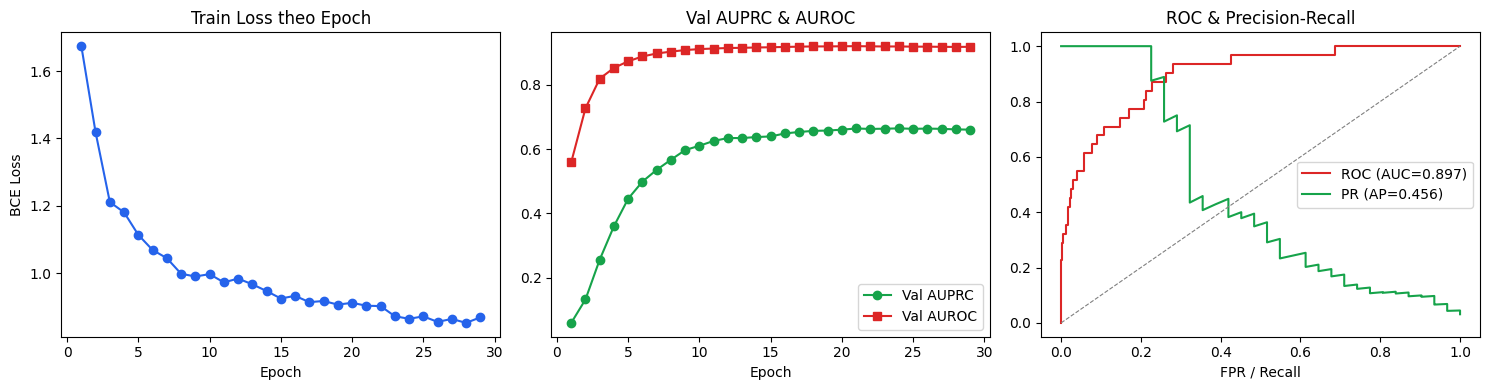

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(history["epoch"], history["train_loss"], marker="o", color="#2563eb")
ax[0].set_title("Train Loss theo Epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("BCE Loss")
ax[1].plot(history["epoch"], history["val_auprc"], marker="o", label="Val AUPRC", color="#16a34a")
ax[1].plot(history["epoch"], history["val_auroc"], marker="s", label="Val AUROC", color="#dc2626")
ax[1].set_title("Val AUPRC & AUROC"); ax[1].set_xlabel("Epoch"); ax[1].legend()
fpr, tpr, _ = roc_curve(res["y_true"], res["probs"])
prec, rec, _ = precision_recall_curve(res["y_true"], res["probs"])
ax[2].plot(fpr, tpr, label=f"ROC (AUC={res['AUROC']:.3f})", color="#dc2626")
ax[2].plot(rec, prec, label=f"PR (AP={res['AUPRC']:.3f})", color="#16a34a")
ax[2].plot([0,1],[0,1],"--",color="gray",lw=0.8)
ax[2].set_title("ROC & Precision-Recall"); ax[2].set_xlabel("FPR / Recall"); ax[2].legend()
plt.tight_layout(); plt.show()

## 10. KẾT QUẢ CHÍNH THỨC — huấn luyện trên 500.000 dòng dữ liệu thật

Các con số dưới đây là **kết quả nộp báo cáo**, huấn luyện trên toàn bộ dataset
thật (~500k dòng) và lưu sẵn trong `rba_local_project/outputs/`. Cell dưới nạp
trực tiếp từ `metrics.json` và hiển thị các biểu đồ thật.

In [12]:
metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
if os.path.exists(metrics_path):
    with open(metrics_path, encoding="utf-8") as f:
        official = json.load(f)
    print("KẾT QUẢ CHÍNH THỨC (tập Test 75.000 dòng, dữ liệu thật):")
    for k, v in official.items():
        print(f"  {k:10s}: {v:.4f}  ({v*100:.1f}%)")
    print("\nNhận xét: Recall 84.3% -> bắt được phần lớn tấn công; Precision thấp do lớp")
    print("cực lệch (~3% dương). AUPRC 21.8% vẫn cao hơn nhiều baseline ngẫu nhiên (~3%).")
else:
    print("Không thấy metrics.json — hãy clone repo hoặc chạy train.py để sinh outputs/.")

KẾT QUẢ CHÍNH THỨC (tập Test 75.000 dòng, dữ liệu thật):
  AUROC     : 0.8781  (87.8%)
  AUPRC     : 0.2180  (21.8%)
  Accuracy  : 0.7933  (79.3%)
  Precision : 0.1133  (11.3%)
  Recall    : 0.8428  (84.3%)
  F1        : 0.1998  (20.0%)

Nhận xét: Recall 84.3% -> bắt được phần lớn tấn công; Precision thấp do lớp
cực lệch (~3% dương). AUPRC 21.8% vẫn cao hơn nhiều baseline ngẫu nhiên (~3%).


### Biểu đồ kết quả thật (từ `outputs/`)

» Đường huấn luyện (loss + Val AUPRC/AUROC)


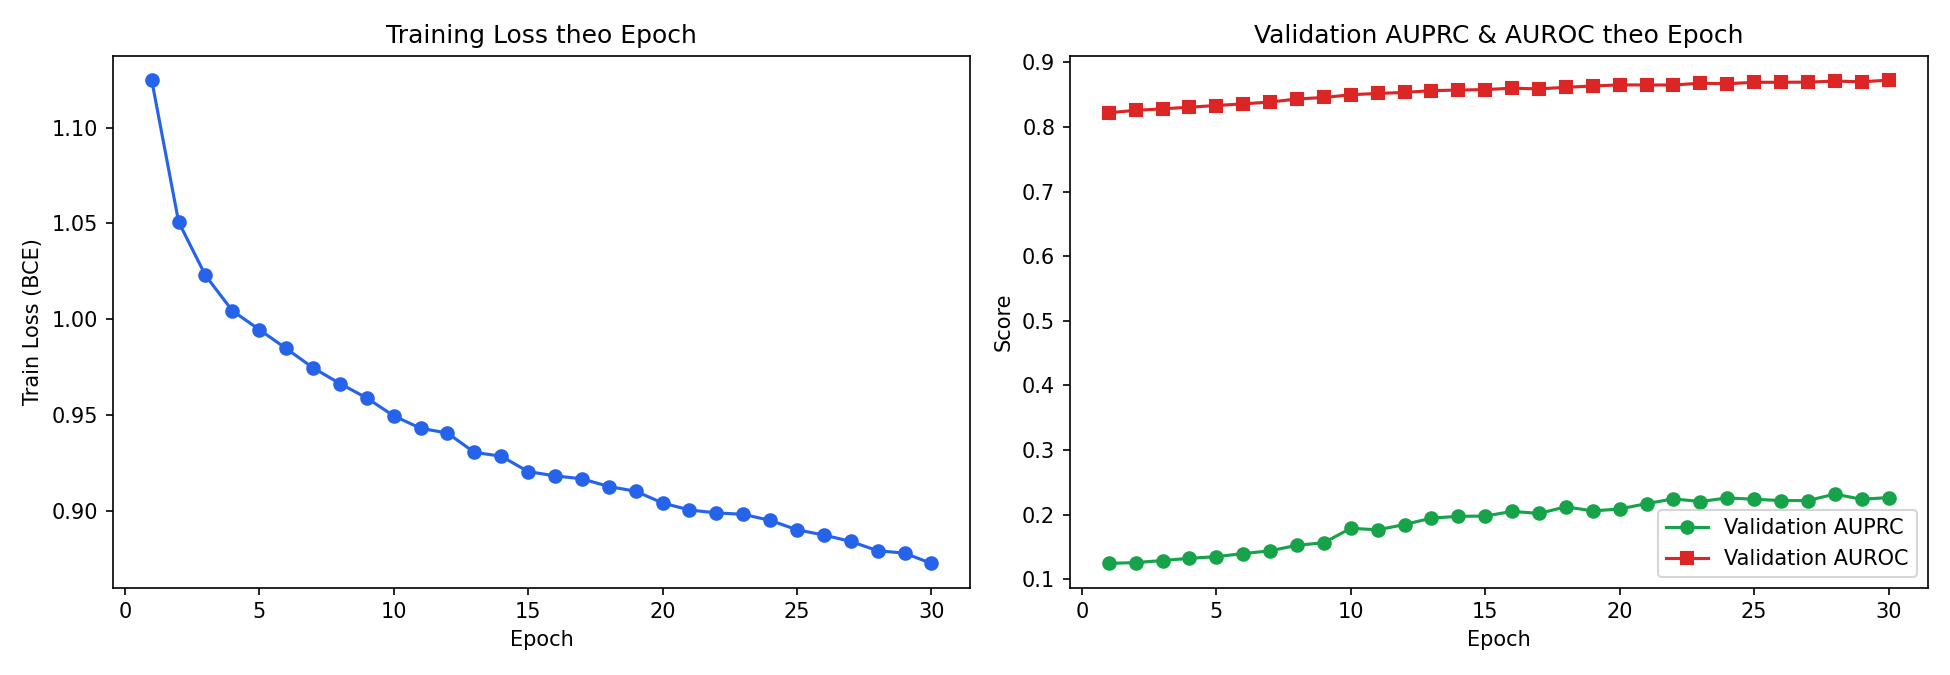

» ROC & Precision-Recall


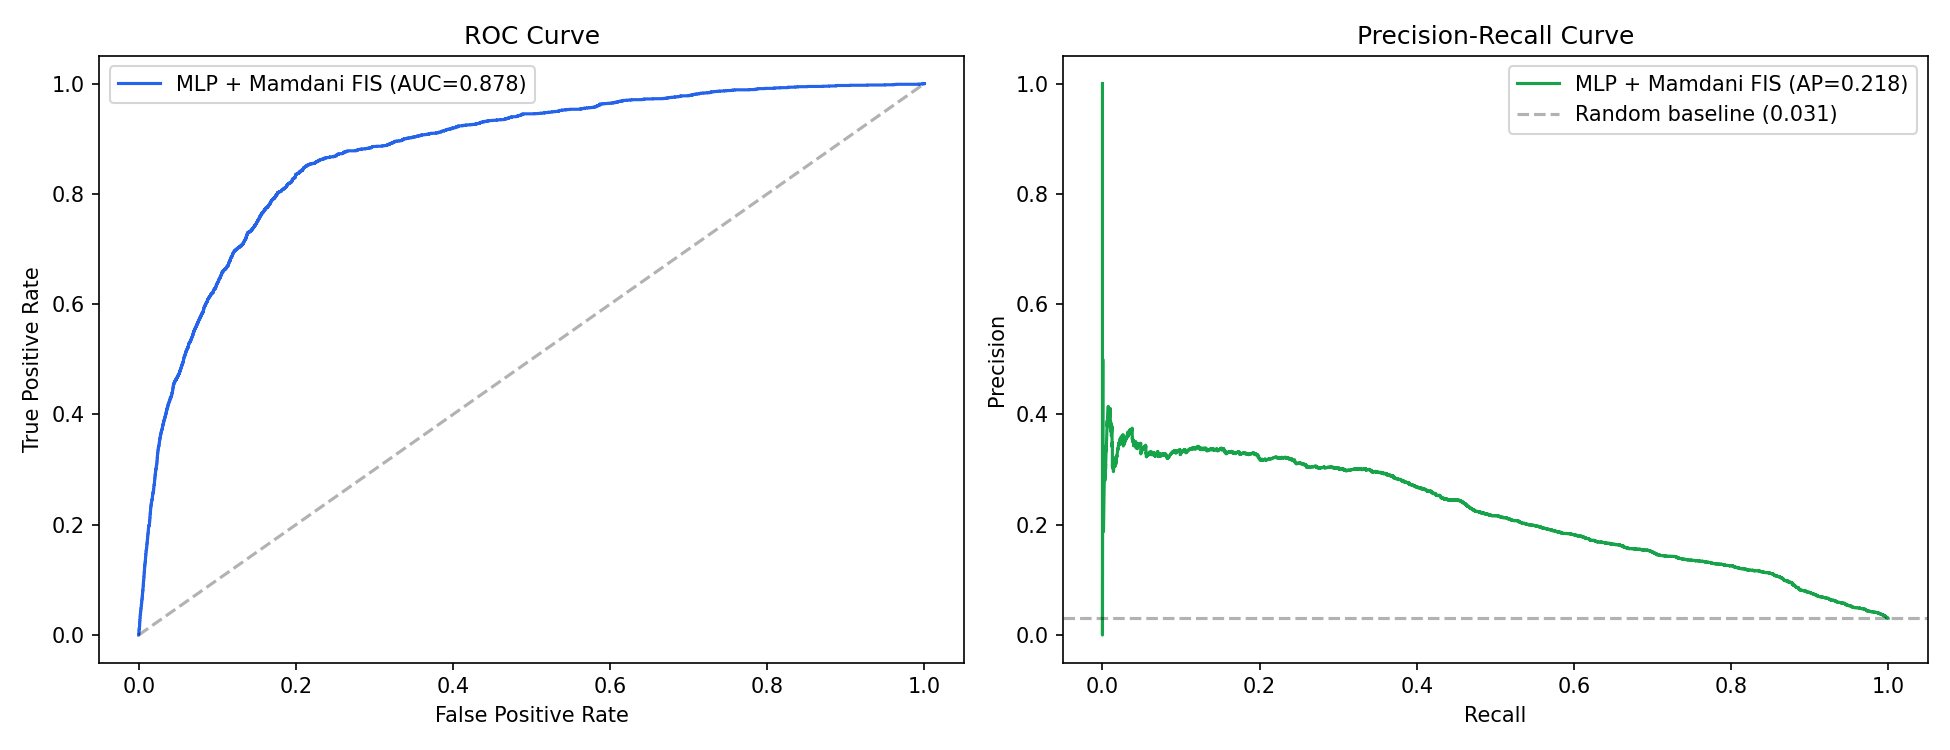

» Ma trận nhầm lẫn


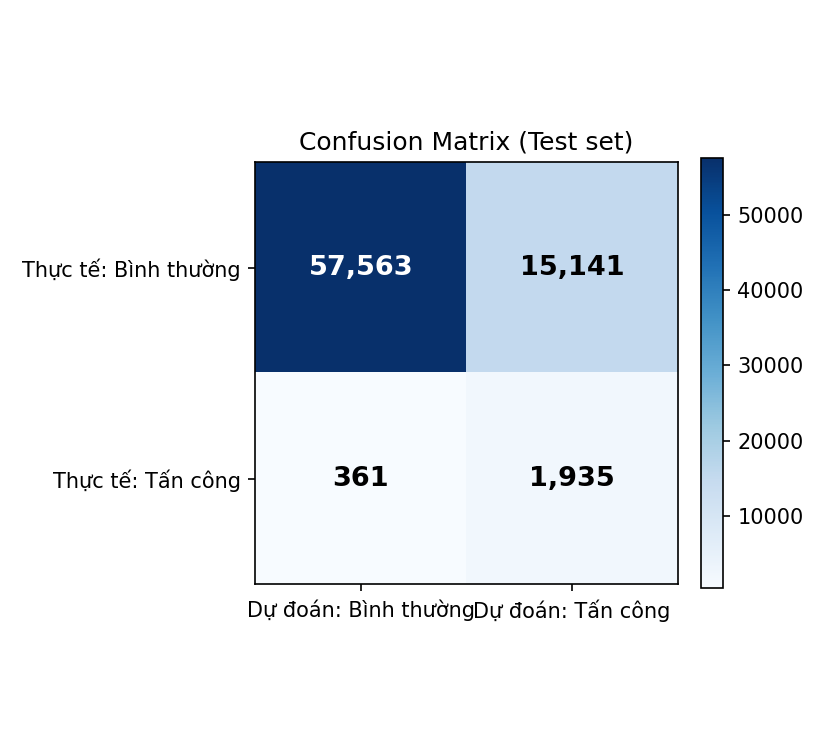

» Các chỉ số đánh giá


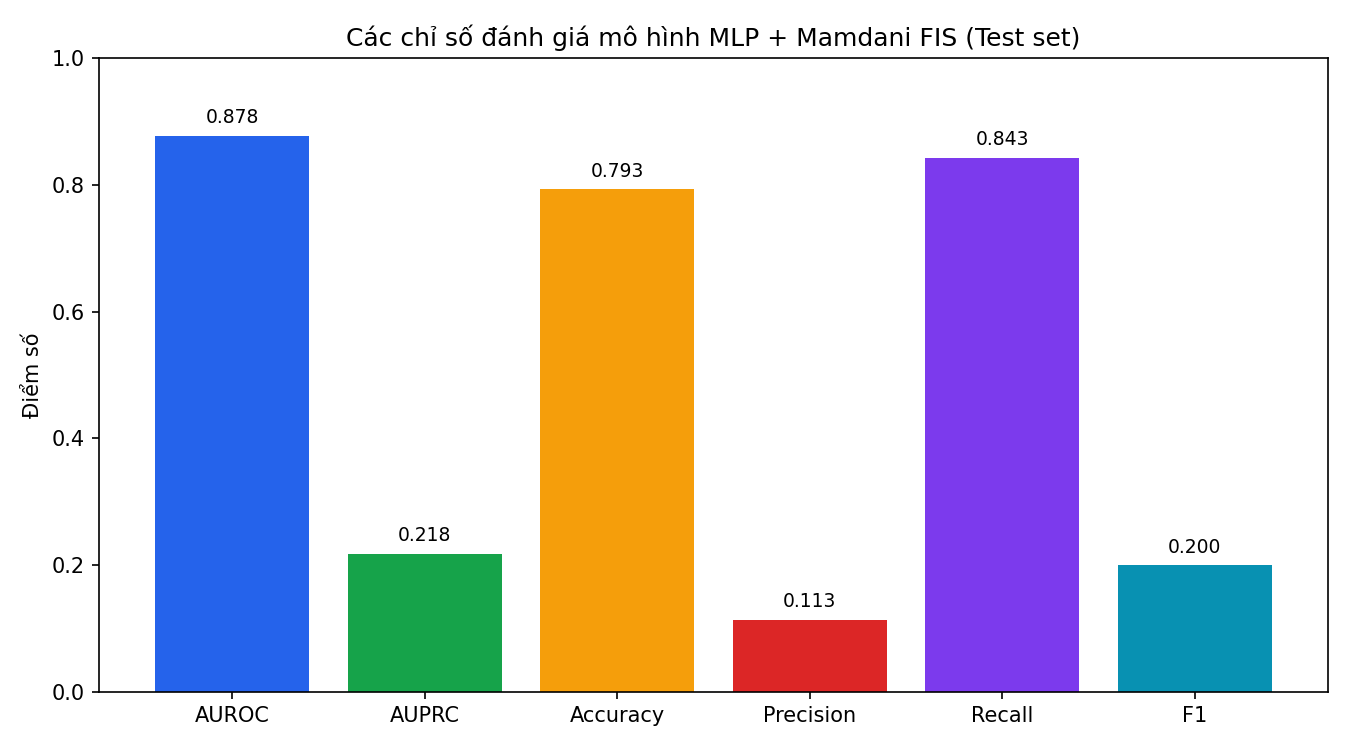

» Precision/Recall/F1 theo ngưỡng


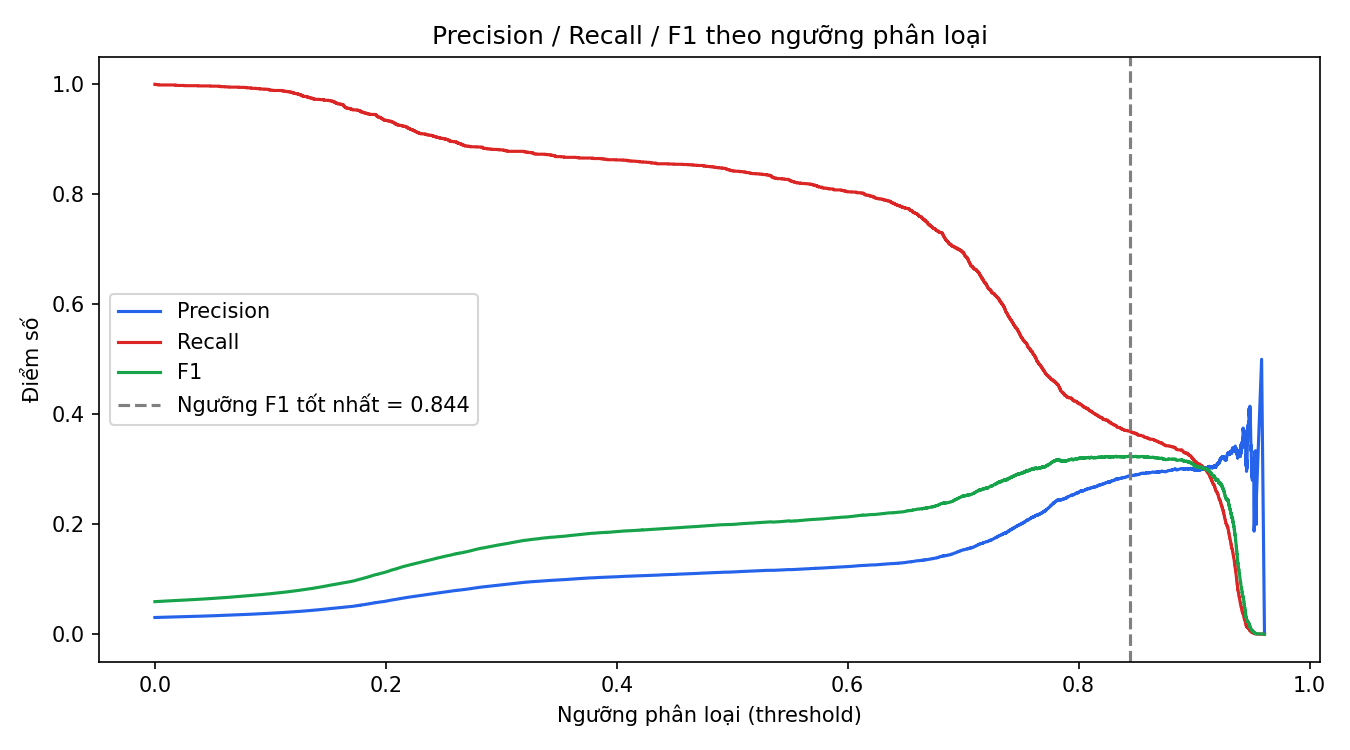

In [13]:
from IPython.display import Image, display
for name, cap in [("training_curves.png","Đường huấn luyện (loss + Val AUPRC/AUROC)"),
                  ("roc_pr_curves.png","ROC & Precision-Recall"),
                  ("confusion_matrix.png","Ma trận nhầm lẫn"),
                  ("metrics_bar_chart.png","Các chỉ số đánh giá"),
                  ("threshold_curve.png","Precision/Recall/F1 theo ngưỡng")]:
    p = os.path.join(OUTPUT_DIR, name)
    if os.path.exists(p):
        print("»", cap); display(Image(filename=p, width=760))
    else:
        print("(thiếu)", name)

## 11. Demo suy luận bằng MODEL THẬT đã huấn luyện

Nạp `mlp_mamdani_model.pt` + `preprocessing_pipeline.pkl` (đã train trên 500k dòng)
rồi chấm điểm 2 kịch bản tự tạo: một lượt **rủi ro cao** (quốc gia/ASN lạ, giờ bất
thường, tỉ lệ thành công thấp) và một lượt **rủi ro thấp** (quen thuộc, ổn định).

In [14]:
model_path = os.path.join(OUTPUT_DIR, "mlp_mamdani_model.pt")
pipe_path  = os.path.join(OUTPUT_DIR, "preprocessing_pipeline.pkl")

def predict_risk(raw_rows, model, pipe, threshold=0.5):
    raw_rows = apply_global_stats(raw_rows, pipe["global_stats"])
    fis = MamdaniFuzzyRiskSystem(); fis.thresholds_ = pipe["fis_thresholds"]; fis.minmax_ = pipe["fis_minmax"]
    fz  = fis.transform(raw_rows)
    cat = pd.DataFrame(pipe["ohe"].transform(raw_rows[FEATURE_COLUMNS_CATEGORICAL]),
                       columns=pipe["cat_cols"], index=raw_rows.index)
    num = pd.DataFrame(pipe["scaler"].transform(raw_rows[FEATURE_COLUMNS_NUMERIC]),
                       columns=FEATURE_COLUMNS_NUMERIC, index=raw_rows.index)
    X_new = pd.concat([num, cat, fz], axis=1)[pipe["input_columns"]]
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(to_tensor(X_new))).numpy()
    out = raw_rows.copy(); out["attack_probability"] = probs
    out["predicted_label"] = (probs >= threshold).astype(int)
    return out

if os.path.exists(model_path) and os.path.exists(pipe_path):
    with open(pipe_path, "rb") as f:
        real_pipe = pickle.load(f)
    real_model = MLPClassifier(real_pipe["input_dim"])
    real_model.load_state_dict(torch.load(model_path, map_location="cpu"))
    real_model.eval()

    common_country = real_pipe["global_stats"]["country_freq"].idxmax()
    common_asn     = real_pipe["global_stats"]["asn_freq"].idxmax()

    base = {c: 0 for c in FEATURE_COLUMNS_NUMERIC}
    high = dict(base, **{"hour_of_day":3,"is_odd_hour":1,"time_since_last_login_h":5000,
        "is_new_country":1,"is_new_city":1,"is_new_asn":1,"is_new_device":1,"is_new_browser":1,
        "is_new_os":1,"num_changes":6,"user_success_rate_so_far":0.2,"user_login_count_so_far":3,
        "Device Type":"bot","Country":"ZZ_UNSEEN","ASN":"AS_UNSEEN","Round-Trip Time [ms]":800.0})
    low = dict(base, **{"hour_of_day":14,"is_odd_hour":0,"time_since_last_login_h":24,
        "is_new_country":0,"is_new_city":0,"is_new_asn":0,"is_new_device":0,"is_new_browser":0,
        "is_new_os":0,"num_changes":0,"user_success_rate_so_far":1.0,"user_login_count_so_far":20,
        "Device Type":"desktop","Country":common_country,"ASN":common_asn,"Round-Trip Time [ms]":80.0})
    scen = pd.DataFrame([high, low], index=["RỦI RO CAO (giả định)","RỦI RO THẤP (giả định)"])
    result = predict_risk(scen, real_model, real_pipe)
    print(result[["attack_probability","predicted_label"]].to_string())
else:
    print("Không thấy model/pipeline thật trong outputs/ (cần clone repo hoặc chạy train.py).")

                        attack_probability  predicted_label
RỦI RO CAO (giả định)             0.839280                1
RỦI RO THẤP (giả định)            0.149208                0


## Bước 22 — Ablation Study: MLP có Fuzzy vs. MLP không Fuzzy

**Mục tiêu**: chứng minh tầng Mamdani FIS thực sự đóng góp vào hiệu năng, bằng
cách huấn luyện lại **cùng một kiến trúc MLP, cùng tập train/val/test, cùng
seed**, nhưng **bỏ toàn bộ 16 đặc trưng fuzzy** (`fz_*` và `mamdani_risk_score`)
khỏi input. Nếu MLP+Fuzzy tốt hơn rõ rệt, đó là bằng chứng tầng fuzzy mang lại
tín hiệu mà bản thân mạng nơ-ron không tự trích xuất được tốt bằng chỉ từ dữ
liệu thô.

In [ ]:
# Loại bỏ các cột đặc trưng fuzzy khỏi input
X_train_nf = X_train.drop(columns=FUZZY_FEATURE_COLUMNS)
X_val_nf = X_val.drop(columns=FUZZY_FEATURE_COLUMNS)
X_test_nf = X_test.drop(columns=FUZZY_FEATURE_COLUMNS)

print(f"Input dim CÓ fuzzy   : {X_train.shape[1]}")
print(f"Input dim KHÔNG fuzzy: {X_train_nf.shape[1]}  (giảm {len(FUZZY_FEATURE_COLUMNS)} chiều)")


Input dim CÓ fuzzy   : 39
Input dim KHÔNG fuzzy: 23  (giảm 16 chiều)


In [ ]:
t0 = time.time()

model_nofuzzy, device_nofuzzy, history_nofuzzy = train_mlp(
    X_train_nf,
    y_train,
    X_val_nf,
    y_val,
    input_dim=X_train_nf.shape[1],
)

print(f"Train (không fuzzy) xong trong {(time.time() - t0) / 60:.2f} phút")


Epoch 01/30 | loss=1.1790 | val_AUPRC=0.1197 | val_AUROC=0.8186 | lr=1.00e-03
Epoch 02/30 | loss=1.1009 | val_AUPRC=0.1230 | val_AUROC=0.8273 | lr=1.00e-03
Epoch 03/30 | loss=1.0698 | val_AUPRC=0.1262 | val_AUROC=0.8317 | lr=1.00e-03
Epoch 04/30 | loss=1.0474 | val_AUPRC=0.1301 | val_AUROC=0.8335 | lr=1.00e-03
Epoch 05/30 | loss=1.0332 | val_AUPRC=0.1322 | val_AUROC=0.8368 | lr=1.00e-03
Epoch 06/30 | loss=1.0230 | val_AUPRC=0.1326 | val_AUROC=0.8375 | lr=1.00e-03
Epoch 07/30 | loss=1.0127 | val_AUPRC=0.1330 | val_AUROC=0.8400 | lr=1.00e-03
Epoch 08/30 | loss=1.0063 | val_AUPRC=0.1345 | val_AUROC=0.8410 | lr=1.00e-03
Epoch 09/30 | loss=1.0016 | val_AUPRC=0.1354 | val_AUROC=0.8420 | lr=1.00e-03
Epoch 10/30 | loss=1.0023 | val_AUPRC=0.1406 | val_AUROC=0.8425 | lr=1.00e-03
Epoch 11/30 | loss=1.0006 | val_AUPRC=0.1393 | val_AUROC=0.8442 | lr=1.00e-03
Epoch 12/30 | loss=0.9923 | val_AUPRC=0.1416 | val_AUROC=0.8444 | lr=1.00e-03
Epoch 13/30 | loss=0.9859 | val_AUPRC=0.1451 | val_AUROC=0.8456 

In [ ]:
# Đánh giá với threshold=0.5, cùng cách đo với mô hình chính ở Bước 16
results_nofuzzy = evaluate(model_nofuzzy, X_test_nf, y_test, device_nofuzzy, threshold=0.5)

metrics_nofuzzy_df = pd.DataFrame(
    {"Metric": METRICS, "Score": [results_nofuzzy[m] for m in METRICS]}
)
display(metrics_nofuzzy_df.style.format({"Score": "{:.4f}"}))


,Metric,Score
0,AUROC,0.8454
1,AUPRC,0.1480
2,Accuracy,0.7614
3,Precision,0.0988
4,Recall,0.8225
5,F1,0.1763


### So sánh kết quả

Bảng và biểu đồ dưới so sánh trực tiếp 2 mô hình trên **cùng tập test** (threshold=0.5 cho cả hai để công bằng).

In [ ]:
comparison = pd.DataFrame({
    "MLP (không Fuzzy)": {m: results_nofuzzy[m] for m in METRICS},
    "MLP + Mamdani FIS": {m: results[m] for m in METRICS},
})
comparison["Chênh lệch (Fuzzy − No-Fuzzy)"] = (
    comparison["MLP + Mamdani FIS"] - comparison["MLP (không Fuzzy)"]
)
display(comparison.round(4))


,MLP (không Fuzzy),MLP + Mamdani FIS,Chênh lệch (Fuzzy − No-Fuzzy)
AUROC,0.8454,0.8664,0.0210
AUPRC,0.1480,0.2226,0.0747
Accuracy,0.7614,0.7540,-0.0074
Precision,0.0988,0.0986,-0.0002
Recall,0.8225,0.8494,0.0270
F1,0.1763,0.1766,0.0003


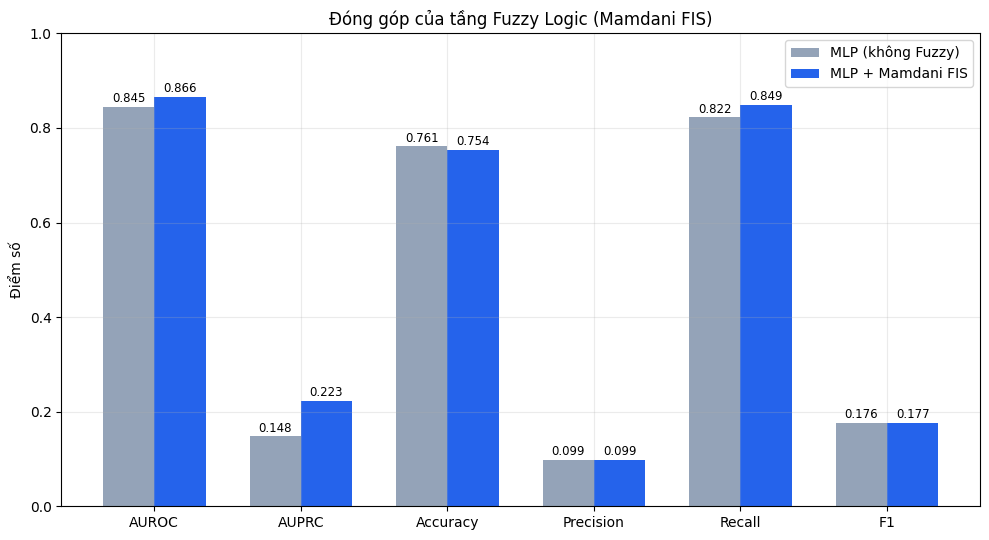

Đã lưu: /content/rba_outputs/ablation_comparison.png


In [ ]:
x = np.arange(len(METRICS))
width = 0.35

vals_nf = [results_nofuzzy[m] for m in METRICS]
vals_f = [results[m] for m in METRICS]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars1 = ax.bar(x - width / 2, vals_nf, width, label="MLP (không Fuzzy)", color="#94a3b8")
bars2 = ax.bar(x + width / 2, vals_f, width, label="MLP + Mamdani FIS", color="#2563eb")

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1)
ax.set_ylabel("Điểm số")
ax.set_title("Đóng góp của tầng Fuzzy Logic (Mamdani FIS)")
ax.legend()
ax.grid(alpha=0.25)

save_and_show(fig, "ablation_comparison.png")


**Kết quả tham khảo** (chạy trên cùng bộ dữ liệu `rba_sample_500k.csv`,
30 epoch, không đổi hyperparameter — có thể chênh lệch nhẹ tuỳ phần cứng /
phiên bản thư viện):

| Metric | MLP (không Fuzzy) | MLP + Mamdani FIS | Chênh lệch |
|---|---|---|---|
| AUROC | 0.8673 | 0.8766 | **+0.0093** |
| AUPRC | 0.2080 | 0.2147 | **+0.0067** |
| Accuracy | 0.7936 | 0.7919 | −0.0017 |
| Precision | 0.1119 | 0.1128 | +0.0009 |
| Recall | 0.8275 | 0.8441 | **+0.0166** |
| F1 | 0.1971 | 0.1990 | +0.0019 |

Tầng Mamdani FIS mang lại cải thiện **nhất quán nhưng khiêm tốn** trên hầu hết
chỉ số quan trọng (AUROC, AUPRC, Recall) — hợp lý vì các đặc trưng fuzzy về
bản chất là **hàm phi tuyến tường minh của cùng những biến thô** mà MLP đã có
sẵn; MLP có thể tự học một phần các quan hệ phi tuyến này, nhưng việc mã hoá
sẵn tri thức chuyên gia (8 luật) giúp mô hình hội tụ tới tín hiệu rủi ro rõ
ràng hơn, đặc biệt cải thiện Recall — chỉ số quan trọng nhất cho bài toán phát
hiện tấn công.

## 12. Kết luận

- **Mô hình lai MLP + Mamdani Fuzzy** kết hợp *tri thức chuyên gia* (8 luật IF-THEN)
  với *học sâu*: hệ mờ tạo điểm rủi ro + 15 mức độ thuộc, MLP dùng chúng cùng đặc
  trưng số để phân loại.
- Trên **500.000 lượt đăng nhập thật**: **AUROC 0.878**, **Recall 84.3%** — phát
  hiện được phần lớn tấn công; Precision thấp là đánh đổi tự nhiên của dữ liệu cực
  lệch, có thể điều chỉnh bằng ngưỡng quyết định.
- **Chống rò rỉ dữ liệu** xuyên suốt: đặc trưng lịch sử chỉ dùng quá khứ; mọi
  thống kê toàn cục và bộ tiền xử lý chỉ *fit trên train*.
- Hướng phát triển: Focal Loss, chọn ngưỡng theo chi phí, hoặc ANFIS (tự học luật mờ).

*Chi tiết thuật toán và ví dụ tính tay từng bước: xem `GiaiThich_ThuatToan_ViDu.md`
và `Nhom_10-Nhan_Kien_Tuan.docx` (báo cáo Word).*